Original class distribution:
Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1953
Brute Force            1470
XSS                     652
Infiltration             36
Sql Injection            21
Heartbleed               11
Name: count, dtype: int64

After removing minority classes (min_samples=1000):
Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1953
Brute Force            1470
Name: count, dtype: int64
New class distribution:
 Label
5     172849
3     128016
0     100000
9      90819
4      10286
8       5933
7       5385
6   

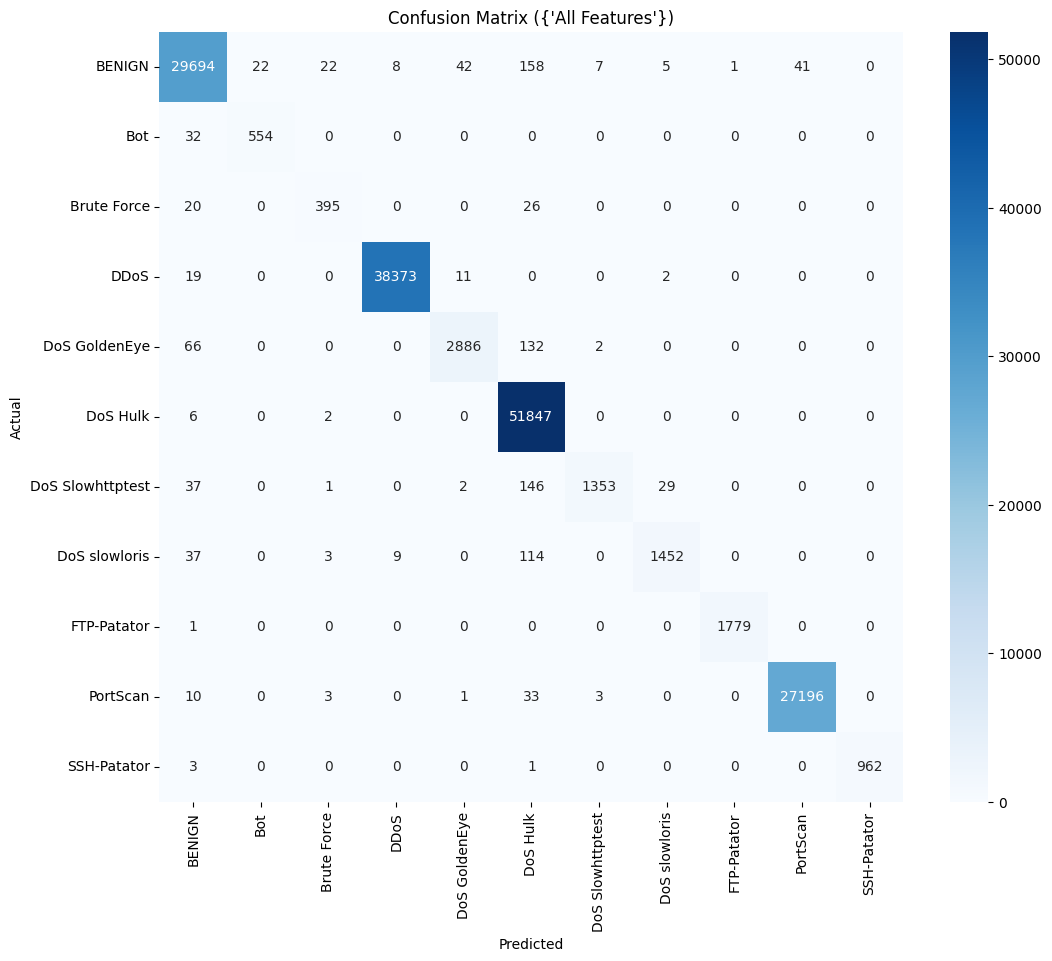

In [ ]:
import xgboost as xgb
import pandas as pd
import time
import numpy as np
import sys
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/Datasets_prepration')
from CICIDS2017 import data_preprocessing, evaluate_model, plot_confusion_matrix

le, X, y, X_train, X_test, y_train, y_test, df  = data_preprocessing()
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
import time
start_total_time = time.time()
xgb_model = xgb.XGBClassifier(random_state=42, learning_rate=0.001, objective='multi:softmax')

start_train_time = time.time()
xgb_model.fit(X_train, y_train)
end_train_time = time.time()
start_pred_time = time.time()
y_pred_encoded_class = xgb_model.predict(X_test)
end_pred_time = time.time()
end_total_time = time.time()

total_time = end_total_time - start_total_time
training_time = end_train_time - start_train_time
prediction_time = end_pred_time - start_pred_time

print("Number of samples before training:", len(X_train))
print(f"Total time: {total_time} seconds")
print(f"Training time: {training_time} seconds")
print(f"Prediction time: {prediction_time} seconds")
y_pred_class = le.inverse_transform(y_pred_encoded_class)
y_test_labels = le.inverse_transform(y_test)

metrics = evaluate_model(y_test_labels, y_pred_class, f" XGBoost ({{'All Features'}})")

plot_confusion_matrix(y_test_labels, y_pred_class, le.classes_, f"Confusion Matrix ({{'All Features'}})")

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')
from SHAP import explain_with_shap
from LIME import explain_with_lime

shap_values, Shap_explainer = explain_with_shap(xgb_model, X_train, X_test, model_type=None, num_samples=5000)
# lime_explianer, Lime_exp_Inst = explain_with_lime(xgb_model, X_train, X_test, mode='classification', num_features=79)


lime_explianer, Lime_exp_Inst = explain_with_lime(
    model=xgb_model,
    X_train=X_train,
    X_test=X_test,
    mode='classification',
    num_features=77,
    num_samples=5000,      
    kernel_width=None,     
    random_state=42,        
    discretize_continuous=True,
    return_instance_exp=True
)



In [2]:
print("SHAP values shape:", shap_values.shape)
print ("SHAP explainer:", Shap_explainer)
# display ("shap_values:", shap_values)

SHAP values shape: (5000, 76, 11)
SHAP explainer: <shap.explainers._tree.TreeExplainer object at 0x736827794af0>


In [ ]:
print("LIME explainer:", lime_explianer)
print("LIME explanation instance:", Lime_exp_Inst)
print("LIME explanation instance details:", Lime_exp_Inst.as_list())


LIME explainer: <lime.lime_tabular.LimeTabularExplainer object at 0x736798e95840>
LIME explanation instance: <lime.explanation.Explanation object at 0x73671ca2f250>
LIME explanation instance details: [('Total Length of Bwd Packets > 0.00', -0.0019603139871975945), ('FIN Flag Count <= -0.36', 0.0016439004974097352), ('-0.31 < Fwd Packet Length Mean <= -0.28', 0.0009492302882734447), ('Total Fwd Packets > 0.00', -0.0008842327087860625), ('-0.09 < Bwd IAT Min <= -0.09', 0.0008581833959121288), ('Destination Port <= -0.30', -0.0007566669331270713), ('PSH Flag Count <= -0.84', 0.000754124604090588), ('act_data_pkt_fwd > -0.00', -0.0007470872505033239), ('-0.00 < Total Backward Packets <= -0.00', 0.0005615802920566611), ('-0.39 < Fwd Packet Length Max <= -0.36', 0.000561369382209162), ('Flow IAT Min <= -0.06', 0.0004790800065423024), ('Bwd Packet Length Max > 0.79', -0.000468289757474611), ('-0.08 < Total Length of Fwd Packets <= 0.01', 0.0004493870067990323), ('min_seg_size_forward <= -0.85

In [4]:
import sys
import importlib

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Evaluation_Metrices')
import Sensitivity
importlib.reload(Sensitivity)

<module 'Sensitivity' from '/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Evaluation_Metrices/Sensitivity.py'>

Number of valid SHAP results (all classes): 4851
First SHAP result: {'mean_absolute_deviation': 0.0024884646, 'cosine_similarity': 0.4953820217467003, 'std_deviation': 0.0027873188}
Number of valid LIME results (all classes): 4851
First LIME result: {'mean_absolute_deviation': 0.0007813570976155231, 'cosine_similarity': 0.21763129583406926, 'std_deviation': 0.00015190424709511985}
Aggregated Sensitivity Metrics (mean ± std):
       mean_absolute_deviation           cosine_similarity            \
                          mean       std              mean       std   
method                                                                 
LIME                  0.000678  0.000068          0.203810  0.209768   
SHAP                  0.001526  0.001779          0.508204  0.340741   

       std_deviation            
                mean       std  
method                          
LIME        0.000154  0.000050  
SHAP        0.001223  0.001131  


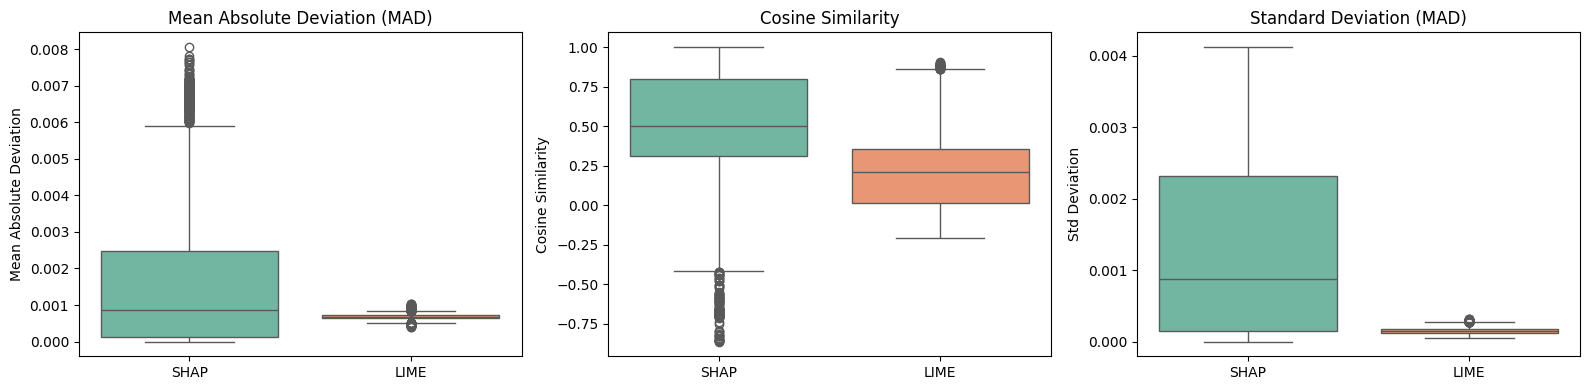

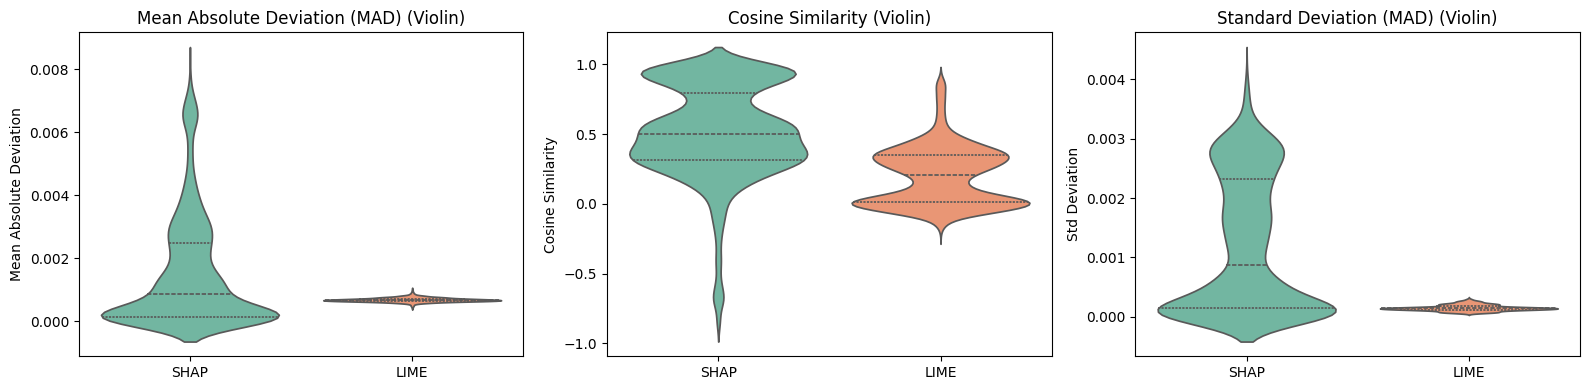


Summary Table (for paper):


,mean_absolute_deviation,cosine_similarity,std_deviation
method,,,
LIME,0.0007 ± 0.0001,0.2038 ± 0.2098,0.0002 ± 0.0001
SHAP,0.0015 ± 0.0018,0.5082 ± 0.3407,0.0012 ± 0.0011


In [ ]:
import sys
import importlib

sys.path.append('../XAI_Evalation_For_IDS_datasets/XAI_Evaluation_Metrices')
import Sensitivity
importlib.reload(Sensitivity)
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit

N_INSTANCES = 1000

def stratified_sample(X, y, n_samples):
    min_class_count = y.value_counts().min()
    if n_samples > min_class_count:
        print(f"Adjusting n_samples from {n_samples} to {min_class_count}")
        n_samples = min_class_count
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=n_samples, random_state=42)
    for _, test_idx in splitter.split(X, y):
        return X.iloc[test_idx], y.iloc[test_idx]

X_sampled, y_sampled = stratified_sample(X_test, y_test, N_INSTANCES)

evaluator = Sensitivity.XAISensitivityEvaluator(model=xgb_model, perturbation_std=0.01, num_perturbations=50)

def eval_all_classes_for_instance(idx, instance):
    if not isinstance(instance, pd.DataFrame):
        instance = pd.DataFrame(instance.reshape(1, -1), columns=X_train.columns, index=[idx])
    if not all(instance.columns == X_train.columns):
        instance = instance[X_train.columns]
    shap_results = evaluator.evaluate_all_classes(instance, Shap_explainer, method='shap')
    lime_results = evaluator.evaluate_all_classes(instance, lime_explianer, method='lime')
    return shap_results, lime_results

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(eval_all_classes_for_instance)(idx, X_sampled.iloc[[i]]) for i, idx in enumerate(X_sampled.index)
)

shap_results = [r for res in results if res is not None for r in (res[0] if res[0] is not None else []) if r is not None]
lime_results = [r for res in results if res is not None for r in (res[1] if res[1] is not None else []) if r is not None]

print(f"SHAP results: {len(shap_results)}")
print(f"LIME results: {len(lime_results)}")

import matplotlib.pyplot as plt
import seaborn as sns

shap_df = pd.DataFrame(shap_results)
lime_df = pd.DataFrame(lime_results)

shap_df['method'] = 'SHAP'
lime_df['method'] = 'LIME'

all_df = pd.concat([shap_df, lime_df], ignore_index=True)

agg_metrics = all_df.groupby('method')[['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']].agg(['mean', 'std'])
print(agg_metrics)

plt.figure(figsize=(16, 4))
metrics = ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']
titles = ['MAD', 'Cosine Similarity', 'Std Deviation']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='method', y=metric, data=all_df, palette='Set2')
    plt.title(title)
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' ').title())
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(1, 3, i+1)
    sns.violinplot(x='method', y=metric, data=all_df, palette='Set2', inner='quartile')
    plt.title(title)
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' ').title())
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame(index=agg_metrics.index)
for col in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    summary_table[col] = agg_metrics[col]['mean'].round(4).astype(str) + " ± " + agg_metrics[col]['std'].round(4).astype(str)
display(summary_table)

In [ ]:
from scipy.stats import mannwhitneyu, shapiro, levene, chi2_contingency
from scipy import stats
import numpy as np

print("Mann-Whitney U Tests")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    stat, p_value = mannwhitneyu(shap_df[metric], lime_df[metric], alternative='two-sided')
    sig = '**' if p_value < 0.001 else ''
    print(f"  {metric}: U={stat:.2f}, p={p_value:.2e} {sig}")

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

print("\nEffect Sizes (Cohen's d)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    d = cohens_d(shap_df[metric], lime_df[metric])
    mag = 'negligible' if abs(d) < 0.2 else 'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'
    print(f"  {metric}: d={d:.2f} ({mag})")

print("\n95% CI (LIME - SHAP)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    shap_vals = shap_df[metric].values
    lime_vals = lime_df[metric].values
    diff = np.mean(lime_vals) - np.mean(shap_vals)
    n1, n2 = len(shap_vals), len(lime_vals)
    s1, s2 = np.std(shap_vals, ddof=1), np.std(lime_vals, ddof=1)
    se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    dof = ((s1**2/n1 + s2**2/n2)**2) / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
    t_crit = stats.t.ppf(0.975, dof)
    ci_lower, ci_upper = diff - t_crit * se_diff, diff + t_crit * se_diff
    print(f"  {metric}: {diff:.6f} [{ci_lower:.6f}, {ci_upper:.6f}]")

print("\nShapiro-Wilk (normality)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    shap_sample = shap_df[metric].sample(min(5000, len(shap_df)), random_state=42)
    lime_sample = lime_df[metric].sample(min(5000, len(lime_df)), random_state=42)
    shap_stat, shap_p = shapiro(shap_sample)
    lime_stat, lime_p = shapiro(lime_sample)
    print(f"  {metric}: SHAP W={shap_stat:.4f} p={shap_p:.2e} | LIME W={lime_stat:.4f} p={lime_p:.2e}")


print("\nLevene's Test (variance equality)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    stat, p_value = levene(shap_df[metric], lime_df[metric])
    print(f"  {metric}: F={stat:.2f}, p={p_value:.4e}")


threshold = 0.95
shap_stable = (shap_df['cosine_similarity'] >= threshold).sum()
lime_stable = (lime_df['cosine_similarity'] >= threshold).sum()

print(f"\nStability (cos_sim >= {threshold})")
print(f"  SHAP: {shap_stable}/{len(shap_df)} ({100*shap_stable/len(shap_df):.1f}%)")
print(f"  LIME: {lime_stable}/{len(lime_df)} ({100*lime_stable/len(lime_df):.1f}%)")

contingency = np.array([
    [shap_stable, len(shap_df) - shap_stable],
    [lime_stable, len(lime_df) - lime_stable]
])
chi2, p_chi, dof, _ = chi2_contingency(contingency)
print(f"  Chi-square: χ²={chi2:.2f}, p={p_chi:.4e}")

STATISTICAL VALIDATION OF XAI SENSITIVITY COMPARISON

1. MANN-WHITNEY U TESTS (all metrics)
--------------------------------------------------------------------------------
mean_absolute_deviation:
  U-statistic: 12515395.00, p-value: 5.57e-08
  Result: ***Highly significant***

cosine_similarity:
  U-statistic: 18845507.00, p-value: 0.00e+00
  Result: ***Highly significant***

std_deviation:
  U-statistic: 17183632.00, p-value: 0.00e+00
  Result: ***Highly significant***


2. EFFECT SIZES (Cohen's d)
--------------------------------------------------------------------------------
Interpretation: |d| < 0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=large

mean_absolute_deviation: d = 0.67 (medium)
cosine_similarity: d = 1.08 (large/very large)
std_deviation: d = 1.34 (large/very large)


3. 95% CONFIDENCE INTERVALS (difference: LIME - SHAP)
--------------------------------------------------------------------------------
mean_absolute_deviation:
  Mean difference: -0.000848
  95% C

[3/4] Evaluating fairness across features...
  - Processing: Destination Port


LIME Fairness:   1%|          | 8/1000 [00:01<03:25,  4.84it/s]

LIME Fairness: 100%|██████████| 1000/1000 [03:42<00:00,  4.49it/s]


  - Processing: Flow Duration


LIME Fairness: 100%|██████████| 1000/1000 [03:34<00:00,  4.66it/s]


  - Processing: Total Fwd Packets


LIME Fairness: 100%|██████████| 1000/1000 [03:40<00:00,  4.54it/s]


  - Processing: PSH Flag Count


LIME Fairness: 100%|██████████| 1000/1000 [04:14<00:00,  3.92it/s]


[4/4] Calculating overall fairness scores...

SAVING RESULTS
✓ Results saved: CICIDS2017_XGBoost_Fairness_Results.csv
✓ Statistical tests saved: CICIDS2017_XGBoost_Fairness_StatisticalTests.csv

GENERATING VISUALIZATIONS
✓ Plot saved: CICIDS2017_XGBoost_MAD_Comparison.png


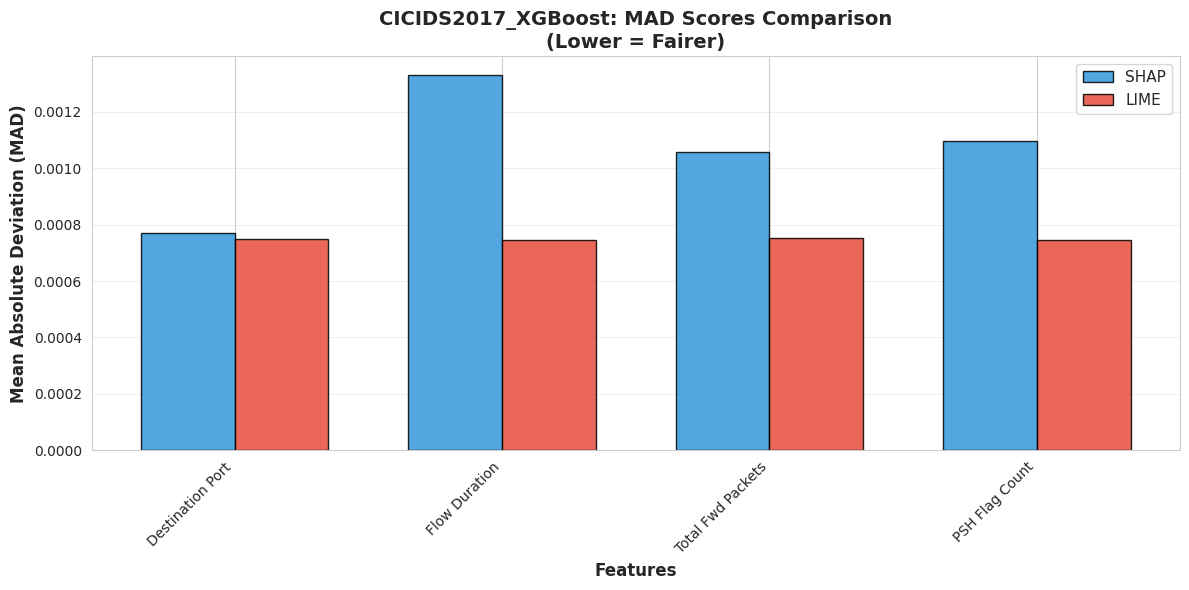

✓ Plot saved: CICIDS2017_XGBoost_Cosine_Comparison.png


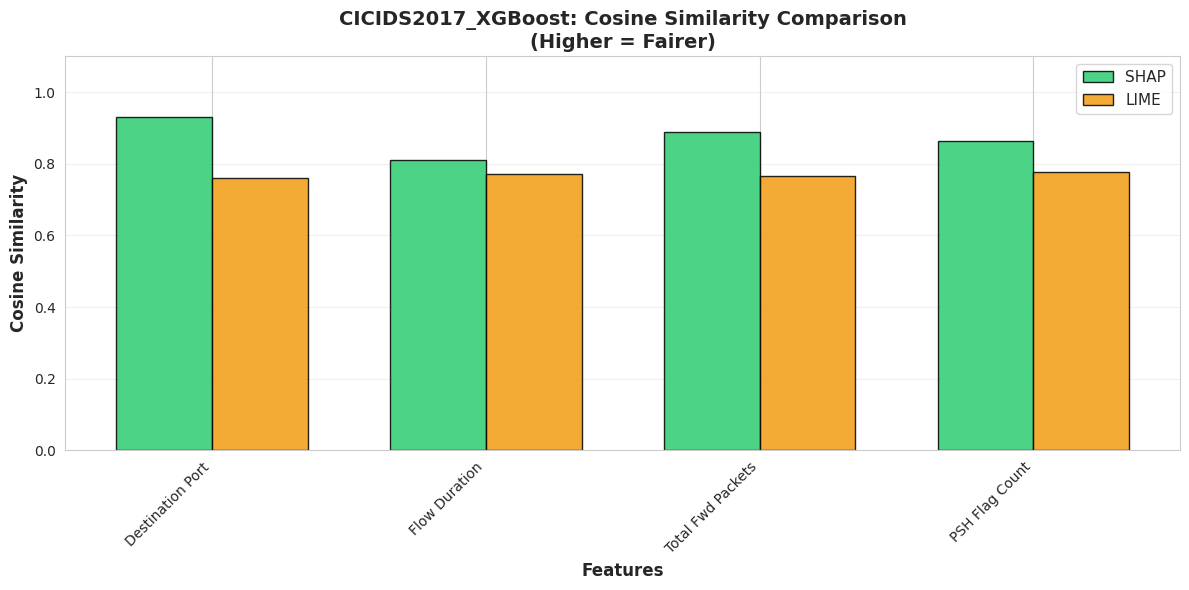

✓ Plot saved: CICIDS2017_XGBoost_Fairness_Scores.png


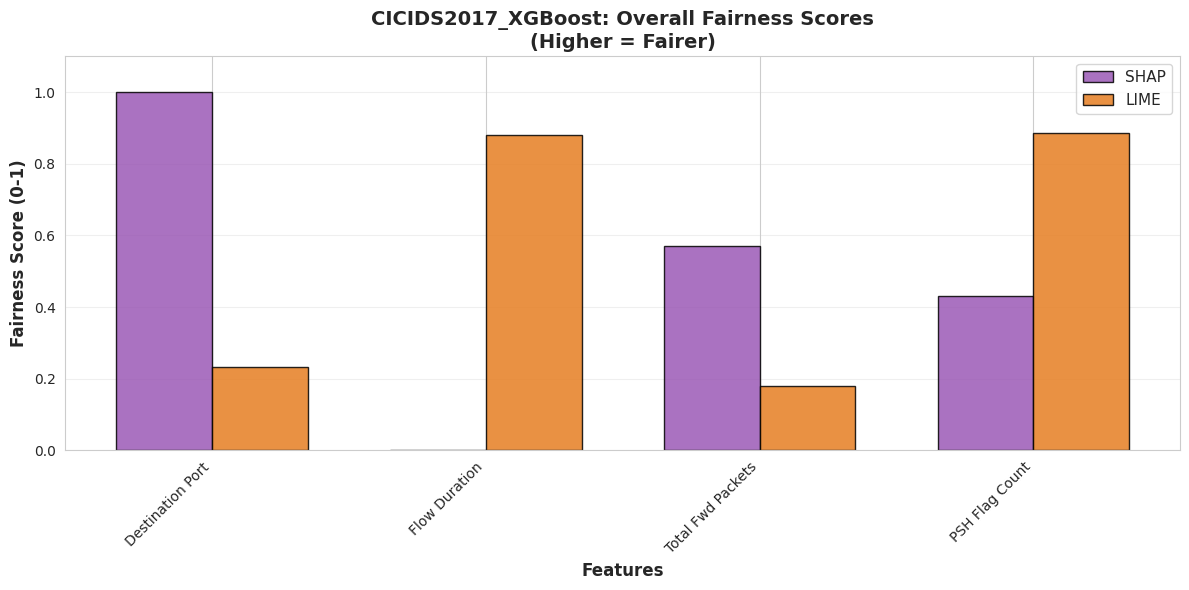


RESULTS SUMMARY


,Model,Feature,SHAP_MAD,LIME_MAD,SHAP_MAD_Std,LIME_MAD_Std,SHAP_Cosine,LIME_Cosine,SHAP_Cosine_Std,LIME_Cosine_Std,MAD_Winner,Cosine_Winner,Num_Instances,SHAP_Fairness_Score,LIME_Fairness_Score,Overall_Winner
0,CICIDS2017_XGBoost,Destination Port,0.000770,0.000748,0.001652,0.000282,0.930798,0.760196,0.281193,0.182185,LIME,SHAP,1000,1.0000,0.2338,SHAP
1,CICIDS2017_XGBoost,Flow Duration,0.001330,0.000744,0.002993,0.000270,0.811009,0.772334,0.455703,0.154254,LIME,SHAP,1000,0.0000,0.8813,LIME
2,CICIDS2017_XGBoost,Total Fwd Packets,0.001056,0.000752,0.002370,0.000280,0.888767,0.765902,0.256934,0.159888,LIME,SHAP,1000,0.5698,0.1793,SHAP
3,CICIDS2017_XGBoost,PSH Flag Count,0.001095,0.000745,0.002413,0.000265,0.864188,0.776112,0.311436,0.147312,LIME,SHAP,1000,0.4319,0.8870,LIME



STATISTICAL VALIDATION


,Feature,MAD_Cohens_d,MAD_Effect_Size,MAD_Significant,Cosine_Cohens_d,Cosine_Effect_Size,Cosine_Significant
0,Destination Port,0.019016,Negligible,Yes,0.719728,Medium,Yes
1,Flow Duration,0.275805,Small,Yes,0.113630,Negligible,Yes
2,Total Fwd Packets,0.180002,Negligible,Yes,0.573887,Medium,Yes
3,PSH Flag Count,0.203564,Small,Yes,0.361365,Small,Yes



 FAIRNESS EVALUATION COMPLETE

 Summary:
  Model: CICIDS2017_XGBoost
  Features evaluated: 4


In [ ]:
sys.path.insert(0, '../XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')
import Explanation Robustness
from Explanation Robustness import XAIFairnessEvaluator

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, shapiro, levene
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

model_name = 'CICIDS2017_DesionTree'
model = xgb_model

candidate_sensitive = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'PSH Flag Count'
]

results_dict = {}
summary_data = []
statistical_tests = []
fairness_scores = []

for sensitive_feature in candidate_sensitive:
    print(f"Processing: {sensitive_feature}")
    
    fairness_evaluator = XAIFairnessEvaluator(
        model=model,
        feature_names=X_test.columns,
        sensitive_feature=sensitive_feature
    )
    
    shap_fairness = fairness_evaluator.evaluate_shap_fairness(
        explainer=Shap_explainer, instances=X_test, num_instances=1000
    )
    
    lime_fairness = fairness_evaluator.evaluate_lime_fairness(
        explainer=lime_explianer, instances=X_test, num_instances=1000
    )
    
    results_dict[sensitive_feature] = {'shap': shap_fairness, 'lime': lime_fairness}
    
    shap_mad_scores = shap_fairness['mad_scores']
    lime_mad_scores = lime_fairness['mad_scores']
    shap_cos_scores = shap_fairness['cosine_sims']
    lime_cos_scores = lime_fairness['cosine_sims']
    
    mad_stat, mad_pval = mannwhitneyu(shap_mad_scores, lime_mad_scores, alternative='two-sided')
    cos_stat, cos_pval = mannwhitneyu(shap_cos_scores, lime_cos_scores, alternative='two-sided')
    
    def cohens_d(group1, group2):
        n1, n2 = len(group1), len(group2)
        var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0
    
    mad_cohens_d = cohens_d(shap_mad_scores, lime_mad_scores)
    cos_cohens_d = cohens_d(shap_cos_scores, lime_cos_scores)
    
    def confidence_interval(data, confidence=0.95):
        mean = np.mean(data)
        se = stats.sem(data)
        margin = se * stats.t.ppf((1 + confidence) / 2., len(data)-1)
        return mean - margin, mean + margin
    
    shap_mad_ci = confidence_interval(shap_mad_scores)
    lime_mad_ci = confidence_interval(lime_mad_scores)
    shap_cos_ci = confidence_interval(shap_cos_scores)
    lime_cos_ci = confidence_interval(lime_cos_scores)
    
    shap_mad_shapiro_p = shapiro(shap_mad_scores)[1]
    lime_mad_shapiro_p = shapiro(lime_mad_scores)[1]
    shap_cos_shapiro_p = shapiro(shap_cos_scores)[1]
    lime_cos_shapiro_p = shapiro(lime_cos_scores)[1]
    
    mad_levene_p = levene(shap_mad_scores, lime_mad_scores)[1]
    cos_levene_p = levene(shap_cos_scores, lime_cos_scores)[1]
    
    def interpret_cohens_d(d):
        abs_d = abs(d)
        if abs_d < 0.2: return "Negligible"
        elif abs_d < 0.5: return "Small"
        elif abs_d < 0.8: return "Medium"
        else: return "Large"
    
    statistical_tests.append({
        'Feature': sensitive_feature,
        'MAD_MannWhitney_U': mad_stat, 'MAD_MannWhitney_p': mad_pval,
        'MAD_Cohens_d': mad_cohens_d, 'MAD_Effect_Size': interpret_cohens_d(mad_cohens_d),
        'MAD_SHAP_CI_Lower': shap_mad_ci[0], 'MAD_SHAP_CI_Upper': shap_mad_ci[1],
        'MAD_LIME_CI_Lower': lime_mad_ci[0], 'MAD_LIME_CI_Upper': lime_mad_ci[1],
        'MAD_SHAP_Shapiro_p': shap_mad_shapiro_p, 'MAD_LIME_Shapiro_p': lime_mad_shapiro_p,
        'MAD_Levene_p': mad_levene_p,
        'Cosine_MannWhitney_U': cos_stat, 'Cosine_MannWhitney_p': cos_pval,
        'Cosine_Cohens_d': cos_cohens_d, 'Cosine_Effect_Size': interpret_cohens_d(cos_cohens_d),
        'Cosine_SHAP_CI_Lower': shap_cos_ci[0], 'Cosine_SHAP_CI_Upper': shap_cos_ci[1],
        'Cosine_LIME_CI_Lower': lime_cos_ci[0], 'Cosine_LIME_CI_Upper': lime_cos_ci[1],
        'Cosine_SHAP_Shapiro_p': shap_cos_shapiro_p, 'Cosine_LIME_Shapiro_p': lime_cos_shapiro_p,
        'Cosine_Levene_p': cos_levene_p,
        'MAD_Significant': 'Yes' if mad_pval < 0.05 else 'No',
        'Cosine_Significant': 'Yes' if cos_pval < 0.05 else 'No'
    })
    
    summary_data.append({
        'Feature': sensitive_feature,
        'SHAP_MAD': f"{shap_fairness['avg_mad']:.6f}",
        'LIME_MAD': f"{lime_fairness['avg_mad']:.6f}",
        'SHAP_MAD_Std': f"{shap_fairness['std_mad']:.6f}",
        'LIME_MAD_Std': f"{lime_fairness['std_mad']:.6f}",
        'SHAP_Cosine': f"{shap_fairness['avg_cosine']:.6f}",
        'LIME_Cosine': f"{lime_fairness['avg_cosine']:.6f}",
        'SHAP_Cosine_Std': f"{shap_fairness['std_cosine']:.6f}",
        'LIME_Cosine_Std': f"{lime_fairness['std_cosine']:.6f}",
        'MAD_Winner': 'SHAP' if shap_fairness['avg_mad'] < lime_fairness['avg_mad'] else 'LIME',
        'Cosine_Winner': 'SHAP' if shap_fairness['avg_cosine'] > lime_fairness['avg_cosine'] else 'LIME',
        'Num_Instances': shap_fairness['num_instances']
    })

from sklearn.preprocessing import MinMaxScaler

features = list(results_dict.keys())
shap_mad = [results_dict[f]['shap']['avg_mad'] for f in features]
lime_mad = [results_dict[f]['lime']['avg_mad'] for f in features]
shap_cosine = [results_dict[f]['shap']['avg_cosine'] for f in features]
lime_cosine = [results_dict[f]['lime']['avg_cosine'] for f in features]

scaler = MinMaxScaler()
shap_mad_norm = 1 - scaler.fit_transform(np.array(shap_mad).reshape(-1, 1)).flatten()
lime_mad_norm = 1 - scaler.fit_transform(np.array(lime_mad).reshape(-1, 1)).flatten()
shap_cosine_norm = scaler.fit_transform(np.array(shap_cosine).reshape(-1, 1)).flatten()
lime_cosine_norm = scaler.fit_transform(np.array(lime_cosine).reshape(-1, 1)).flatten()

shap_fairness_score = (shap_mad_norm + shap_cosine_norm) / 2
lime_fairness_score = (lime_mad_norm + lime_cosine_norm) / 2

for i, feature in enumerate(features):
    fairness_scores.append({
        'Feature': feature,
        'SHAP_Fairness_Score': f"{shap_fairness_score[i]:.4f}",
        'LIME_Fairness_Score': f"{lime_fairness_score[i]:.4f}",
        'Overall_Winner': 'SHAP' if shap_fairness_score[i] > lime_fairness_score[i] else 'LIME'
    })

summary_df = pd.DataFrame(summary_data)
stats_df = pd.DataFrame(statistical_tests)
fairness_df = pd.DataFrame(fairness_scores)

main_df = summary_df.copy()
for col in ['SHAP_Fairness_Score', 'LIME_Fairness_Score', 'Overall_Winner']:
    main_df[col] = fairness_df[col]
main_df.insert(0, 'Model', model_name)

main_df.to_csv(f'{model_name}_Fairness_Results.csv', index=False)
stats_df.insert(0, 'Model', model_name)
stats_df.to_csv(f'{model_name}_Fairness_StatisticalTests.csv', index=False)
print(f"Saved: {model_name}_Fairness_Results.csv, {model_name}_Fairness_StatisticalTests.csv")

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(12, 6))
features_list = main_df['Feature'].values
shap_mad = [float(val) for val in main_df['SHAP_MAD'].values]
lime_mad = [float(val) for val in main_df['LIME_MAD'].values]

x = np.arange(len(features_list))
width = 0.35

ax.bar(x - width/2, shap_mad, width, label='SHAP', color='#3498db', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_mad, width, label='LIME', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('MAD', fontsize=12)
ax.set_title(f'{model_name}: MAD Comparison')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
shap_cos = [float(val) for val in main_df['SHAP_Cosine'].values]
lime_cos = [float(val) for val in main_df['LIME_Cosine'].values]

ax.bar(x - width/2, shap_cos, width, label='SHAP', color='#2ecc71', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_cos, width, label='LIME', color='#f39c12', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title(f'{model_name}: Cosine Similarity Comparison')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
shap_scores = [float(val) for val in main_df['SHAP_Fairness_Score'].values]
lime_scores = [float(val) for val in main_df['LIME_Fairness_Score'].values]

ax.bar(x - width/2, shap_scores, width, label='SHAP', color='#9b59b6', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_scores, width, label='LIME', color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Fairness Score', fontsize=12)
ax.set_title(f'{model_name}: Fairness Scores')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

display(main_df)
display(stats_df[['Feature', 'MAD_Cohens_d', 'MAD_Effect_Size', 'MAD_Significant', 
                   'Cosine_Cohens_d', 'Cosine_Effect_Size', 'Cosine_Significant']])

print(f"\nModel: {model_name}, Features: {len(candidate_sensitive)}")

In [ ]:
import sys
import importlib

if 'Fidelity' in sys.modules:
    del sys.modules['Fidelity']
sys.path.insert(0, '../XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')

import Fidelity
importlib.reload(Fidelity)
from Fidelity import shap_neighborhood_fidelity, lime_neighborhood_fidelity

import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelBinarizer

plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("Set2")

def clfi_for_instance(model_probs, surrogate_probs):
    """Compute composite local fidelity index."""
    y_m = model_probs.argmax(axis=1)
    y_s = surrogate_probs.argmax(axis=1)
    p_acc = (y_m == y_s).mean()

    mae = np.abs(model_probs - surrogate_probs).mean()
    p_mae = 1 - (mae / 2.0)

    rho, _ = spearmanr(model_probs.flatten(), surrogate_probs.flatten())
    p_rank = (np.nan_to_num(rho, nan=0.0) + 1) / 2

    prob_true = model_probs.max(axis=1)
    prob_pred = surrogate_probs.max(axis=1)
    conf_diff = np.abs(prob_true - prob_pred).mean()
    p_cal = 1 - conf_diff

    return float(np.clip((p_acc + p_mae + p_rank + p_cal) / 4, 0, 1))

n_perturb = 50
noise_std = 0.01
random_state = 42

min_per_class = 20
strat_indices = []
for class_id in range(len(np.unique(y_test))):
    class_indices = np.where(y_test.values == class_id)[0]
    if len(class_indices) == 0:
        continue
    take = min(min_per_class, len(class_indices))
    sampled = np.random.choice(class_indices, size=take, replace=False)
    strat_indices.extend(sampled)

sample_indices = np.array(strat_indices)
num_samples = len(sample_indices)
print(f"Samples: {num_samples} (min_per_class={min_per_class})")

try:
    shap_link = 'logit' if getattr(Shap_explainer, 'model_output', None) in ('raw', 'margin', 'log_odds') else 'identity'
except:
    shap_link = 'logit'

shap_fidelities = []
lime_fidelities = []
per_class_shap = defaultdict(list)
per_class_lime = defaultdict(list)
shap_clfis, lime_clfis = [], []

for i, idx in enumerate(sample_indices):
    if (i + 1) % 50 == 0:
        print(f"Progress: {i + 1}/{num_samples}")

    instance = X_test.iloc[idx:idx+1].copy()
    label = y_test.iloc[idx]

    shap_fid = shap_neighborhood_fidelity(
        explainer=Shap_explainer, model=xgb_model, instance=instance,
        n_perturb=n_perturb, noise_std=noise_std, task_type='classification',
        random_state=random_state, link=shap_link
    )

    lime_fid = lime_neighborhood_fidelity(
        model=xgb_model, instance=instance, n_perturb=n_perturb,
        noise_std=noise_std, task_type='classification', random_state=random_state
    )

    shap_fidelities.append(shap_fid)
    lime_fidelities.append(lime_fid)
    per_class_shap[label].append(shap_fid)
    per_class_lime[label].append(lime_fid)

    noise = np.random.default_rng(random_state).normal(0, noise_std, size=(n_perturb, instance.shape[1]))
    X_pert = instance.values + noise
    model_probs = xgb_model.predict_proba(X_pert)

    sv = Shap_explainer.shap_values(X_pert, check_additivity=False)

    if isinstance(sv, list):
        n_classes = len(sv)
        sv_list = sv
    else:
        sv_arr = np.asarray(sv)
        if sv_arr.ndim == 3:
            n_classes = sv_arr.shape[2]
            sv_list = [sv_arr[:, :, c] for c in range(n_classes)]
        else:
            n_classes = 1
            sv_list = [sv_arr]

    base_raw = np.array(Shap_explainer.expected_value)
    if base_raw.ndim == 0:
        base_arr = np.repeat(base_raw, n_classes)
    else:
        base_arr = base_raw.reshape(-1)
        if base_arr.size < n_classes:
            base_arr = np.pad(base_arr, (0, n_classes - base_arr.size), mode="edge")
        elif base_arr.size > n_classes:
            base_arr = base_arr[:n_classes]

    scores = np.stack([base_arr[c] + sv_list[c].sum(axis=1) for c in range(n_classes)], axis=1)
    scores = scores - scores.max(axis=1, keepdims=True)
    shap_sur_probs = np.exp(scores)
    shap_sur_probs = shap_sur_probs / shap_sur_probs.sum(axis=1, keepdims=True)

    distances = np.linalg.norm(X_pert - instance.values, axis=1)
    kw = np.sqrt(instance.shape[1])
    w = np.exp(-(distances ** 2) / (kw ** 2))

    n_classes = model_probs.shape[1]
    y_pred_classes = model_probs.argmax(axis=1)
    lb = LabelBinarizer()
    lb.fit(range(n_classes))
    y_enc = lb.transform(y_pred_classes)

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_pert, y_enc, sample_weight=w)
    lime_sur_probs = ridge.predict(X_pert)
    lime_sur_probs = np.clip(lime_sur_probs, 0, 1)
    lime_sur_probs = lime_sur_probs / lime_sur_probs.sum(axis=1, keepdims=True)

    shap_clfis.append(clfi_for_instance(model_probs, shap_sur_probs))
    lime_clfis.append(clfi_for_instance(model_probs, lime_sur_probs))


class_names = le.inverse_transform(sorted(set(y_test)))
table = {
    "Method": ["SHAP", "LIME"],
    "Fidelity": [
        f"{np.mean(shap_fidelities):.4f} ± {np.std(shap_fidelities):.4f}",
        f"{np.mean(lime_fidelities):.4f} ± {np.std(lime_fidelities):.4f}"
    ],
    "CLFI": [
        f"{np.mean(shap_clfis):.4f} ± {np.std(shap_clfis):.4f}",
        f"{np.mean(lime_clfis):.4f} ± {np.std(lime_clfis):.4f}"
    ]
}

for i, cname in enumerate(class_names):
    shap_mean = np.mean(per_class_shap[i]) if per_class_shap[i] else np.nan
    shap_std = np.std(per_class_shap[i]) if per_class_shap[i] else np.nan
    lime_mean = np.mean(per_class_lime[i]) if per_class_lime[i] else np.nan
    lime_std = np.std(per_class_lime[i]) if per_class_lime[i] else np.nan
    table[cname] = [f"{shap_mean:.4f} ± {shap_std:.4f}", f"{lime_mean:.4f} ± {lime_std:.4f}"]

df_table = pd.DataFrame(table)
display(df_table)


fidelity_df = pd.DataFrame({
    'SHAP': shap_fidelities,
    'LIME': lime_fidelities,
    'class': [le.inverse_transform([lbl])[0] for lbl in y_test.iloc[sample_indices].values]
})
fidelity_long = fidelity_df.melt(id_vars='class', value_vars=['SHAP', 'LIME'],
                                 var_name='Method', value_name='Fidelity')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Method', y='Fidelity', data=fidelity_long,
            palette=['#66c2a5', '#fc8d62'], width=0.5, ax=axes[0])
means = fidelity_long.groupby('Method')['Fidelity'].mean()
for i, (method, mean_val) in enumerate(means.items()):
    axes[0].plot(i, mean_val, marker='D', markersize=8, color='darkred', 
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)
axes[0].set_title('Global Fidelity')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, linestyle='--')

sns.violinplot(x='class', y='Fidelity', hue='Method', data=fidelity_long,
              palette=['#66c2a5', '#fc8d62'], split=True, inner='quartile', ax=axes[1])
axes[1].set_title('Per-Class Fidelity')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


summary_stats = fidelity_long.groupby(['Method', 'class'])['Fidelity'].agg(['mean', 'std', 'min', 'max', 'count']).reset_index()
display(summary_stats)

print(f"\nCLFI - SHAP: {np.mean(shap_clfis):.4f} ± {np.std(shap_clfis):.4f}")
print(f"CLFI - LIME: {np.mean(lime_clfis):.4f} ± {np.std(lime_clfis):.4f}")


from scipy.stats import wilcoxon

shap_arr = np.array(shap_fidelities)
lime_arr = np.array(lime_fidelities)
shap_clfi_arr = np.array(shap_clfis)
lime_clfi_arr = np.array(lime_clfis)

w_stat_fid, p_fid = wilcoxon(shap_arr, lime_arr, alternative='greater', zero_method='wilcox')
w_stat_clfi, p_clfi = wilcoxon(shap_clfi_arr, lime_clfi_arr, alternative='greater', zero_method='wilcox')

def cliffs_delta(a, b):
    comp = np.subtract.outer(a, b)
    return float((comp > 0).sum() - (comp < 0).sum()) / comp.size

delta_fid = cliffs_delta(shap_arr, lime_arr)
delta_clfi = cliffs_delta(shap_clfi_arr, lime_clfi_arr)

def bootstrap_diff_ci(a, b, n_boot=4000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(a)
    diffs = [np.mean(a[rng.integers(0, n, size=n)] - b[rng.integers(0, n, size=n)]) for _ in range(n_boot)]
    return float(np.mean(a - b)), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

mean_diff_fid, lo_fid, hi_fid = bootstrap_diff_ci(shap_arr, lime_arr)
mean_diff_clfi, lo_clfi, hi_clfi = bootstrap_diff_ci(shap_clfi_arr, lime_clfi_arr)

print(f"\nWilcoxon (SHAP > LIME):")
print(f"  Fidelity: W={w_stat_fid}, p={p_fid:.3e}, diff={mean_diff_fid:.4f} [{lo_fid:.4f}, {hi_fid:.4f}], δ={delta_fid:.3f}")
print(f"  CLFI: W={w_stat_clfi}, p={p_clfi:.3e}, diff={mean_diff_clfi:.4f} [{lo_clfi:.4f}, {hi_clfi:.4f}], δ={delta_clfi:.3f}")

# Baselines
from sklearn.metrics import accuracy_score
y_true = xgb_model.predict(X_test.values)
y_rand = np.random.default_rng(0).integers(low=0, high=len(np.unique(y_true)), size=len(y_true))
print(f"\nBaselines - Perfect: {accuracy_score(y_true, y_true):.3f}, Random: {accuracy_score(y_true, y_rand):.3f}")